In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("fixed_income.csv")

In [4]:
df.info

<bound method DataFrame.info of       Unnamed: 0                       Financial Instrument  Coupon  Maturity  \
0              0                   SMMSBK CORP CD 82869ADY8   5.450  Jul25'24   
1              1                   BRISBK CORP CD 110001AS3   5.300  Jul26'24   
2              2                      SYF CORP CD 87164WN95   3.300  Jul29'24   
3              3                   FBFCEN CORP CD 319267KV1   5.250  Jul29'24   
4              4                      COF CORP CD 14042TJA6   3.350  Aug05'24   
...          ...                                        ...     ...       ...   
4433        5273   US-T GOVT Note STRIPS Interest 912834RQ3   0.000  Jul31'24   
4434        5274  US-T GOVT Note STRIPS Principal 9128207S0   0.000  Jul31'24   
4435        5275                   US-T GOVT Note 9128282N9   2.125  Jul31'24   
4436        5276                   US-T GOVT Bill 912797KR7   0.000  Jul30'24   
4437        5277                   US-T GOVT Bill 912797JT5   0.000  Jul25'24

In [5]:
df.shape

(4438, 16)

In [6]:
df.isna().sum()

Unnamed: 0                0
Financial Instrument      0
Coupon                    0
Maturity                  0
Ratings                   0
Issuer Debt/Equity        0
Issue Date                0
Time-To-Maturity (TTM)    0
Payment Frequency         0
Ask                       0
Ask Yield                 0
Duration %                0
Convexity                 0
Bid                       0
Unnamed: 13               0
Instrument Type           0
dtype: int64

In [7]:
df.columns

Index(['Unnamed: 0', 'Financial Instrument', 'Coupon', 'Maturity', 'Ratings',
       'Issuer Debt/Equity', 'Issue Date', 'Time-To-Maturity (TTM)',
       'Payment Frequency', 'Ask', 'Ask Yield', 'Duration %  ', 'Convexity',
       'Bid', 'Unnamed: 13', 'Instrument Type'],
      dtype='object')

In [8]:
df.dtypes

Unnamed: 0                  int64
Financial Instrument       object
Coupon                    float64
Maturity                   object
Ratings                    object
Issuer Debt/Equity         object
Issue Date                 object
Time-To-Maturity (TTM)    float64
Payment Frequency          object
Ask                       float64
Ask Yield                 float64
Duration %                 object
Convexity                  object
Bid                        object
Unnamed: 13               float64
Instrument Type            object
dtype: object

In [9]:
df = df.rename(columns = {"Unnamed: 0": "ticker"})

In [10]:
df

,ticker,Financial Instrument,Coupon,Maturity,Ratings,Issuer Debt/Equity,Issue Date,Time-To-Maturity (TTM),Payment Frequency,Ask,Ask Yield,Duration %,Convexity,Bid,Unnamed: 13,Instrument Type
0,0,SMMSBK CORP CD 82869ADY8,5.450,Jul25'24,0,0,Oct 25 '23,0.01,Monthly,100.00500,3.5110,0.005479452200233936,0.0000003,99.851,0.0,Certificates of Deposit
1,1,BRISBK CORP CD 110001AS3,5.300,Jul26'24,0,0,Jul 28 '23,0.01,Monthly,99.99800,5.6450,0.008219177834689617,0.00000068,99.850,0.0,Certificates of Deposit
2,2,SYF CORP CD 87164WN95,3.300,Jul29'24,0,0,Jul 29 '22,0.02,Semi-Annual,99.96700,5.6280,0.016438355669379234,0.0000027,99.813,0.0,Certificates of Deposit
3,3,FBFCEN CORP CD 319267KV1,5.250,Jul29'24,0,0,Jun 29 '23,0.02,Semi-Annual,99.99500,5.5960,0.016438355669379234,0.0000027,99.846,0.0,Certificates of Deposit
4,4,COF CORP CD 14042TJA6,3.350,Aug05'24,0,0,Aug 03 '22,0.04,Semi-Annual,99.92100,5.6890,0.5218930244445801,0.0027642634231597185,99.881,0.0,Certificates of Deposit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,5273,US-T GOVT Note STRIPS Interest 912834RQ3,0.000,Jul31'24,0,0,Jul 31 '17,0.02,0,99.89500,5.4820,0,0,99.89499,0.0,Treasuries
4434,5274,US-T GOVT Note STRIPS Principal 9128207S0,0.000,Jul31'24,0,0,Jul 31 '17,0.02,0,99.90300,5.0730,0,0,99.893,0.0,Treasuries
4435,5275,US-T GOVT Note 9128282N9,2.125,Jul31'24,AAA (MOODY),0,Jul 31 '17,0.02,Semi-Annual,99.94531,4.9210,0.02190280705690384,0.0000048,99.933,0.0,Treasuries
4436,5276,US-T GOVT Bill 912797KR7,0.000,Jul30'24,0,0,Apr 02 '24,0.02,0,99.91320,5.2125,0,0,99.913,0.0,Treasuries


In [11]:
df.columns = (
    df.columns
        .str.lower()
        .str.replace(" ", "_", regex = False)
        .str.replace("/", "by", regex = False)
        .str.replace("%", "pct", regex = False)
        .str.replace("-", "_", regex = False)
        .str.replace("(", "", regex = False)
        .str.replace(")", "", regex = False)
        .str.strip()
)

In [12]:
df

,ticker,financial_instrument,coupon,maturity,ratings,issuer_debtbyequity,issue_date,time_to_maturity_ttm,payment_frequency,ask,ask_yield,duration_pct__,convexity,bid,unnamed:_13,instrument_type
0,0,SMMSBK CORP CD 82869ADY8,5.450,Jul25'24,0,0,Oct 25 '23,0.01,Monthly,100.00500,3.5110,0.005479452200233936,0.0000003,99.851,0.0,Certificates of Deposit
1,1,BRISBK CORP CD 110001AS3,5.300,Jul26'24,0,0,Jul 28 '23,0.01,Monthly,99.99800,5.6450,0.008219177834689617,0.00000068,99.850,0.0,Certificates of Deposit
2,2,SYF CORP CD 87164WN95,3.300,Jul29'24,0,0,Jul 29 '22,0.02,Semi-Annual,99.96700,5.6280,0.016438355669379234,0.0000027,99.813,0.0,Certificates of Deposit
3,3,FBFCEN CORP CD 319267KV1,5.250,Jul29'24,0,0,Jun 29 '23,0.02,Semi-Annual,99.99500,5.5960,0.016438355669379234,0.0000027,99.846,0.0,Certificates of Deposit
4,4,COF CORP CD 14042TJA6,3.350,Aug05'24,0,0,Aug 03 '22,0.04,Semi-Annual,99.92100,5.6890,0.5218930244445801,0.0027642634231597185,99.881,0.0,Certificates of Deposit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,5273,US-T GOVT Note STRIPS Interest 912834RQ3,0.000,Jul31'24,0,0,Jul 31 '17,0.02,0,99.89500,5.4820,0,0,99.89499,0.0,Treasuries
4434,5274,US-T GOVT Note STRIPS Principal 9128207S0,0.000,Jul31'24,0,0,Jul 31 '17,0.02,0,99.90300,5.0730,0,0,99.893,0.0,Treasuries
4435,5275,US-T GOVT Note 9128282N9,2.125,Jul31'24,AAA (MOODY),0,Jul 31 '17,0.02,Semi-Annual,99.94531,4.9210,0.02190280705690384,0.0000048,99.933,0.0,Treasuries
4436,5276,US-T GOVT Bill 912797KR7,0.000,Jul30'24,0,0,Apr 02 '24,0.02,0,99.91320,5.2125,0,0,99.913,0.0,Treasuries


In [13]:
df["maturity"] = pd.to_datetime(df["maturity"])
df["issue_date"] = pd.to_datetime(df["issue_date"])

C:\Users\aleks\AppData\Local\Temp\ipykernel_31676\312346904.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["maturity"] = pd.to_datetime(df["maturity"])
C:\Users\aleks\AppData\Local\Temp\ipykernel_31676\312346904.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_date"] = pd.to_datetime(df["issue_date"])


In [14]:
df

,ticker,financial_instrument,coupon,maturity,ratings,issuer_debtbyequity,issue_date,time_to_maturity_ttm,payment_frequency,ask,ask_yield,duration_pct__,convexity,bid,unnamed:_13,instrument_type
0,0,SMMSBK CORP CD 82869ADY8,5.450,2024-07-25,0,0,2023-10-25,0.01,Monthly,100.00500,3.5110,0.005479452200233936,0.0000003,99.851,0.0,Certificates of Deposit
1,1,BRISBK CORP CD 110001AS3,5.300,2024-07-26,0,0,2023-07-28,0.01,Monthly,99.99800,5.6450,0.008219177834689617,0.00000068,99.850,0.0,Certificates of Deposit
2,2,SYF CORP CD 87164WN95,3.300,2024-07-29,0,0,2022-07-29,0.02,Semi-Annual,99.96700,5.6280,0.016438355669379234,0.0000027,99.813,0.0,Certificates of Deposit
3,3,FBFCEN CORP CD 319267KV1,5.250,2024-07-29,0,0,2023-06-29,0.02,Semi-Annual,99.99500,5.5960,0.016438355669379234,0.0000027,99.846,0.0,Certificates of Deposit
4,4,COF CORP CD 14042TJA6,3.350,2024-08-05,0,0,2022-08-03,0.04,Semi-Annual,99.92100,5.6890,0.5218930244445801,0.0027642634231597185,99.881,0.0,Certificates of Deposit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,5273,US-T GOVT Note STRIPS Interest 912834RQ3,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.89500,5.4820,0,0,99.89499,0.0,Treasuries
4434,5274,US-T GOVT Note STRIPS Principal 9128207S0,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.90300,5.0730,0,0,99.893,0.0,Treasuries
4435,5275,US-T GOVT Note 9128282N9,2.125,2024-07-31,AAA (MOODY),0,2017-07-31,0.02,Semi-Annual,99.94531,4.9210,0.02190280705690384,0.0000048,99.933,0.0,Treasuries
4436,5276,US-T GOVT Bill 912797KR7,0.000,2024-07-30,0,0,2024-04-02,0.02,0,99.91320,5.2125,0,0,99.913,0.0,Treasuries


In [15]:
df.isna().sum()

ticker                  0
financial_instrument    0
coupon                  0
maturity                0
ratings                 0
issuer_debtbyequity     0
issue_date              0
time_to_maturity_ttm    0
payment_frequency       0
ask                     0
ask_yield               0
duration_pct__          0
convexity               0
bid                     0
unnamed:_13             0
instrument_type         0
dtype: int64

In [16]:
num_cols = df.select_dtypes(include = "number").columns.drop("ticker")

In [17]:
num_cols

Index(['coupon', 'time_to_maturity_ttm', 'ask', 'ask_yield', 'unnamed:_13'], dtype='object')

In [18]:
df[num_cols] 

,coupon,time_to_maturity_ttm,ask,ask_yield,unnamed:_13
0,5.450,0.01,100.00500,3.5110,0.0
1,5.300,0.01,99.99800,5.6450,0.0
2,3.300,0.02,99.96700,5.6280,0.0
3,5.250,0.02,99.99500,5.5960,0.0
4,3.350,0.04,99.92100,5.6890,0.0
...,...,...,...,...,...
4433,0.000,0.02,99.89500,5.4820,0.0
4434,0.000,0.02,99.90300,5.0730,0.0
4435,2.125,0.02,99.94531,4.9210,0.0
4436,0.000,0.02,99.91320,5.2125,0.0


In [19]:
print((df[num_cols] > 0).sum())

coupon                  4334
time_to_maturity_ttm    4438
ask                     4438
ask_yield               4438
unnamed:_13                0
dtype: int64


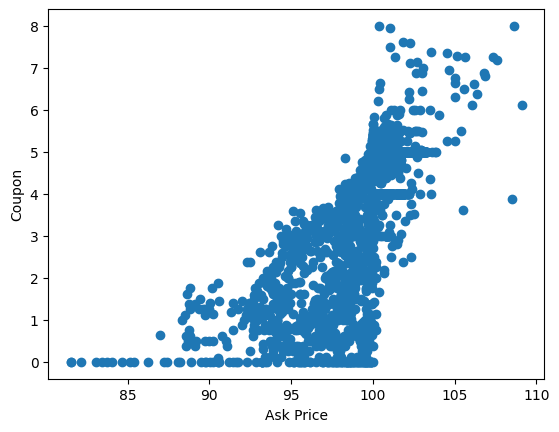

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df["ask"], df["coupon"])
plt.xlabel("Ask Price")
plt.ylabel("Coupon")
plt.show()

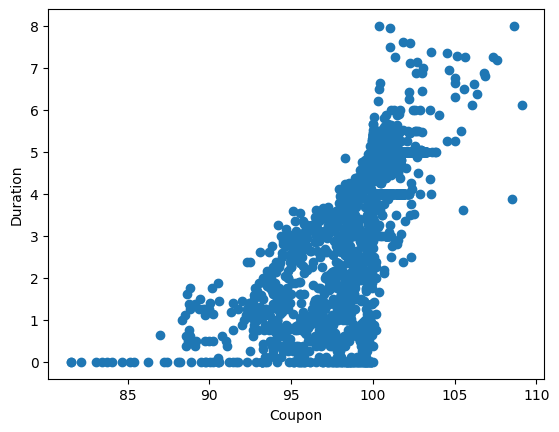

In [31]:
plt.scatter(df["ask"], df["coupon"])
plt.xlabel("Coupon")
plt.ylabel("Duration")
plt.show()

In [32]:
df.columns

Index(['ticker', 'financial_instrument', 'coupon', 'maturity', 'ratings',
       'issuer_debtbyequity', 'issue_date', 'time_to_maturity_ttm',
       'payment_frequency', 'ask', 'ask_yield', 'duration_pct__', 'convexity',
       'bid', 'unnamed:_13', 'instrument_type'],
      dtype='object')

In [34]:
import time


def timer(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, *kwargs)
        end = time.perf_counter()
        print(f"{func.__name__}: has taken {end - start} seconds")
        return result
    return wrapper

In [35]:
@timer
def df_lower(df: pd.DataFrame, column: str) -> pd.Series:
    return df[column].str.lower()

In [37]:
print(df_lower(df, "instrument_type"))

df_lower: has taken 0.003571299952454865 seconds
0       certificates of deposit
1       certificates of deposit
2       certificates of deposit
3       certificates of deposit
4       certificates of deposit
                 ...           
4433                 treasuries
4434                 treasuries
4435                 treasuries
4436                 treasuries
4437                 treasuries
Name: instrument_type, Length: 4438, dtype: object


In [38]:
df["instrument_type"] = df["instrument_type"].astype("string[pyarrow]")

In [39]:
print(df_lower(df, "instrument_type"))

df_lower: has taken 0.002576800005044788 seconds
0       certificates of deposit
1       certificates of deposit
2       certificates of deposit
3       certificates of deposit
4       certificates of deposit
                 ...           
4433                 treasuries
4434                 treasuries
4435                 treasuries
4436                 treasuries
4437                 treasuries
Name: instrument_type, Length: 4438, dtype: string


In [42]:
df.columns.duplicated().sum()

0

In [45]:
df.isna().mean().sort_values()

ticker                  0.0
financial_instrument    0.0
coupon                  0.0
maturity                0.0
ratings                 0.0
issuer_debtbyequity     0.0
issue_date              0.0
time_to_maturity_ttm    0.0
payment_frequency       0.0
ask                     0.0
ask_yield               0.0
duration_pct__          0.0
convexity               0.0
bid                     0.0
unnamed:_13             0.0
instrument_type         0.0
dtype: float64

In [46]:
df.groupby("instrument_type")["ask_yield"].mean()

instrument_type
Certificates of Deposit    4.765269
Corporate Bonds            4.602916
Municipal Bonds            2.780455
Treasuries                 4.513842
Name: ask_yield, dtype: float64

In [48]:
df.groupby("ratings")["ask_yield"].mean().sort_values(ascending = False)

ratings
NR (MOODY)      4.686100
A1 (MOODY)      4.098355
0               4.035844
WR (MOODY)      3.867163
A3 (MOODY)      3.862190
BAA1 (MOODY)    3.701500
A2 (MOODY)      3.565303
AAA (MOODY)     3.441196
NoMD            3.283843
AA3 (MOODY)     3.259514
AA2 (MOODY)     3.105843
AA1 (MOODY)     2.931005
BAA3 (MOODY)    2.874000
BAA2 (MOODY)    0.890800
Name: ask_yield, dtype: float64

<Axes: xlabel='time_to_maturity_ttm', ylabel='ask_yield'>

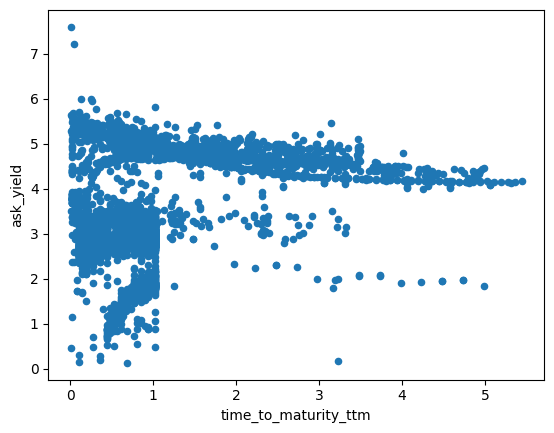

In [49]:
df.plot.scatter(
    x = "time_to_maturity_ttm",
    y = "ask_yield"
)

<Axes: xlabel='time_to_maturity_ttm', ylabel='ask_yield'>

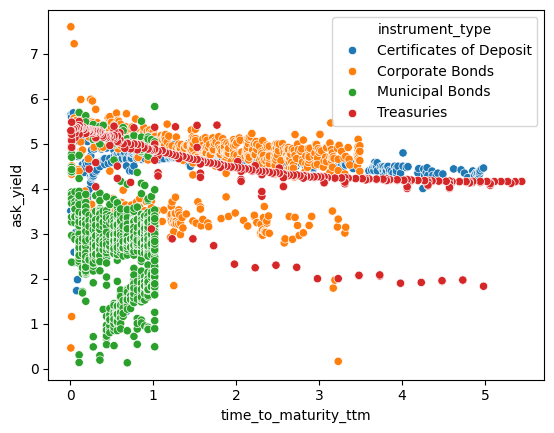

In [50]:
import seaborn as sns

sns.scatterplot(
    data = df,
    x = "time_to_maturity_ttm",
    y = "ask_yield",
    hue = "instrument_type"
)

In [68]:
df["duration_pct__"] = pd.to_numeric(
    df["duration_pct__"],
    errors = "coerce"
)

In [69]:
df["duration_pct__"].isna().sum()

308

In [70]:
df.groupby("instrument_type")["duration_pct__"].mean()

instrument_type
Certificates of Deposit    1.571713
Corporate Bonds            1.351635
Municipal Bonds            0.000891
Treasuries                 1.039680
Name: duration_pct__, dtype: float64

In [71]:
num_cols = df.select_dtypes(include = "number").columns.drop("ticker")

In [72]:
num_cols

Index(['coupon', 'time_to_maturity_ttm', 'ask', 'ask_yield', 'duration_pct__',
       'unnamed:_13'],
      dtype='object')

In [73]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

In [74]:
df[num_cols].dtypes

coupon                  float64
time_to_maturity_ttm    float64
ask                     float64
ask_yield               float64
duration_pct__          float64
unnamed:_13             float64
dtype: object

In [75]:
df.groupby("instrument_type")["duration_pct__"].mean()

instrument_type
Certificates of Deposit    1.571713
Corporate Bonds            1.351635
Municipal Bonds            0.000891
Treasuries                 1.039680
Name: duration_pct__, dtype: float64

In [76]:
df.sort_values("duration_pct__", ascending = False).head(10)

,ticker,financial_instrument,coupon,maturity,ratings,issuer_debtbyequity,issue_date,time_to_maturity_ttm,payment_frequency,ask,ask_yield,duration_pct__,convexity,bid,unnamed:_13,instrument_type
4086,4925,US-T GOVT Note 912828YS3,1.750,2029-11-15,AAA (MOODY),0.0,2019-11-15,5.31,Semi-Annual,88.78907,4.122,5.065170,0.2648217976093292,88.767,0.0,Treasuries
4095,4934,US-T GOVT Note TIPS 9128287D6,0.250,2029-07-15,AAA (MOODY),0.0,2019-07-31,4.98,Semi-Annual,92.49610,1.835,4.948335,0.2457777112722396,92.48,0.0,Treasuries
4084,4923,US-T GOVT Note 91282CGB1,3.875,2029-12-31,AAA (MOODY),0.0,2023-01-03,5.44,Semi-Annual,98.60157,4.165,4.945320,0.2597395181655884,98.601,0.0,Treasuries
4085,4924,US-T GOVT Note 91282CFY2,3.875,2029-11-30,AAA (MOODY),0.0,2022-11-30,5.36,Semi-Annual,98.64532,4.160,4.860455,0.2514190077781677,98.64531,0.0,Treasuries
4090,4929,US-T GOVT Note 912828YB0,1.625,2029-08-15,AAA (MOODY),0.0,2019-08-15,5.06,Semi-Annual,88.64649,4.134,4.829270,0.2409927099943161,88.637,0.0,Treasuries
4087,4926,US-T GOVT Note 91282CFT3,4.000,2029-10-31,AAA (MOODY),0.0,2022-10-31,5.27,Semi-Annual,99.23325,4.163,4.765382,0.2425999641418457,99.23322,0.0,Treasuries
4088,4927,US-T GOVT Note 91282CFL0,3.875,2029-09-30,AAA (MOODY),0.0,2022-09-30,5.19,Semi-Annual,98.66994,4.163,4.693219,0.2354518622159958,98.66991,0.0,Treasuries
4089,4928,US-T GOVT Note 91282CFJ5,3.125,2029-08-31,AAA (MOODY),0.0,2022-08-31,5.11,Semi-Annual,95.27473,4.162,4.691604,0.2331691533327102,95.27471,0.0,Treasuries
4094,4933,US-T GOVT Note 91282CFC0,2.625,2029-07-31,AAA (MOODY),0.0,2022-08-01,5.02,Semi-Annual,93.09644,4.165,4.663895,0.2289854288101196,93.09641,0.0,Treasuries
4097,4936,US-T GOVT Note 91282CEV9,3.250,2029-06-30,AAA (MOODY),0.0,2022-06-30,4.94,Semi-Annual,95.95212,4.166,4.589012,0.2206613421440124,95.9521,0.0,Treasuries


In [80]:
shock = 0.01

df["price_impact_pct"] = -df["duration_pct__"] * shock

In [81]:
df["price_impact"] = df["price_impact_pct"] * df["ask"]

In [84]:
df["convexity"] = pd.to_numeric(
    df["convexity"],
    errors = "coerce"
)

In [85]:
df["price_impact_convexity"] = (
    -df["duration_pct__"] * shock
    + 0.5 * df["convexity"] * shock ** 2
) * df["ask"]

In [86]:
df

,ticker,financial_instrument,coupon,maturity,ratings,issuer_debtbyequity,issue_date,time_to_maturity_ttm,payment_frequency,ask,ask_yield,duration_pct__,convexity,bid,unnamed:_13,instrument_type,price_impace_pct,price_impact_pct,price_impact,price_impact_convexity
0,0,SMMSBK CORP CD 82869ADY8,5.450,2024-07-25,0,0,2023-10-25,0.01,Monthly,100.00500,3.5110,0.005479,3.000000e-07,99.851,0.0,Certificates of Deposit,-0.000055,-0.000055,-0.005480,-0.005480
1,1,BRISBK CORP CD 110001AS3,5.300,2024-07-26,0,0,2023-07-28,0.01,Monthly,99.99800,5.6450,0.008219,6.800000e-07,99.850,0.0,Certificates of Deposit,-0.000082,-0.000082,-0.008219,-0.008219
2,2,SYF CORP CD 87164WN95,3.300,2024-07-29,0,0,2022-07-29,0.02,Semi-Annual,99.96700,5.6280,0.016438,2.700000e-06,99.813,0.0,Certificates of Deposit,-0.000164,-0.000164,-0.016433,-0.016433
3,3,FBFCEN CORP CD 319267KV1,5.250,2024-07-29,0,0,2023-06-29,0.02,Semi-Annual,99.99500,5.5960,0.016438,2.700000e-06,99.846,0.0,Certificates of Deposit,-0.000164,-0.000164,-0.016438,-0.016438
4,4,COF CORP CD 14042TJA6,3.350,2024-08-05,0,0,2022-08-03,0.04,Semi-Annual,99.92100,5.6890,0.521893,2.764263e-03,99.881,0.0,Certificates of Deposit,-0.005219,-0.005219,-0.521481,-0.521467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,5273,US-T GOVT Note STRIPS Interest 912834RQ3,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.89500,5.4820,0.000000,0.000000e+00,99.89499,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000
4434,5274,US-T GOVT Note STRIPS Principal 9128207S0,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.90300,5.0730,0.000000,0.000000e+00,99.893,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000
4435,5275,US-T GOVT Note 9128282N9,2.125,2024-07-31,AAA (MOODY),0,2017-07-31,0.02,Semi-Annual,99.94531,4.9210,0.021903,4.800000e-06,99.933,0.0,Treasuries,-0.000219,-0.000219,-0.021891,-0.021891
4436,5276,US-T GOVT Bill 912797KR7,0.000,2024-07-30,0,0,2024-04-02,0.02,0,99.91320,5.2125,0.000000,0.000000e+00,99.913,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000


In [90]:
df["bid"] = pd.to_numeric(
    df["bid"],
    errors = "coerce"
)

In [91]:
df["bid_ask_spread"] = df["ask"] - df["bid"]

df["bid_ask_spread_pct"] = df["bid_ask_spread"] / df["ask"]

In [92]:
df.groupby("instrument_type")["bid_ask_spread_pct"].mean()

instrument_type
Certificates of Deposit    0.009162
Corporate Bonds            0.003027
Municipal Bonds            0.660378
Treasuries                 0.000468
Name: bid_ask_spread_pct, dtype: float64

In [93]:
df

,ticker,financial_instrument,coupon,maturity,ratings,issuer_debtbyequity,issue_date,time_to_maturity_ttm,payment_frequency,ask,...,convexity,bid,unnamed:_13,instrument_type,price_impace_pct,price_impact_pct,price_impact,price_impact_convexity,bid_ask_spread,bid_ask_spread_pct
0,0,SMMSBK CORP CD 82869ADY8,5.450,2024-07-25,0,0,2023-10-25,0.01,Monthly,100.00500,...,3.000000e-07,99.85100,0.0,Certificates of Deposit,-0.000055,-0.000055,-0.005480,-0.005480,0.15400,1.539923e-03
1,1,BRISBK CORP CD 110001AS3,5.300,2024-07-26,0,0,2023-07-28,0.01,Monthly,99.99800,...,6.800000e-07,99.85000,0.0,Certificates of Deposit,-0.000082,-0.000082,-0.008219,-0.008219,0.14800,1.480030e-03
2,2,SYF CORP CD 87164WN95,3.300,2024-07-29,0,0,2022-07-29,0.02,Semi-Annual,99.96700,...,2.700000e-06,99.81300,0.0,Certificates of Deposit,-0.000164,-0.000164,-0.016433,-0.016433,0.15400,1.540508e-03
3,3,FBFCEN CORP CD 319267KV1,5.250,2024-07-29,0,0,2023-06-29,0.02,Semi-Annual,99.99500,...,2.700000e-06,99.84600,0.0,Certificates of Deposit,-0.000164,-0.000164,-0.016438,-0.016438,0.14900,1.490075e-03
4,4,COF CORP CD 14042TJA6,3.350,2024-08-05,0,0,2022-08-03,0.04,Semi-Annual,99.92100,...,2.764263e-03,99.88100,0.0,Certificates of Deposit,-0.005219,-0.005219,-0.521481,-0.521467,0.04000,4.003162e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433,5273,US-T GOVT Note STRIPS Interest 912834RQ3,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.89500,...,0.000000e+00,99.89499,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000,0.00001,1.001051e-07
4434,5274,US-T GOVT Note STRIPS Principal 9128207S0,0.000,2024-07-31,0,0,2017-07-31,0.02,0,99.90300,...,0.000000e+00,99.89300,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000,0.01000,1.000971e-04
4435,5275,US-T GOVT Note 9128282N9,2.125,2024-07-31,AAA (MOODY),0,2017-07-31,0.02,Semi-Annual,99.94531,...,4.800000e-06,99.93300,0.0,Treasuries,-0.000219,-0.000219,-0.021891,-0.021891,0.01231,1.231674e-04
4436,5276,US-T GOVT Bill 912797KR7,0.000,2024-07-30,0,0,2024-04-02,0.02,0,99.91320,...,0.000000e+00,99.91300,0.0,Treasuries,-0.000000,-0.000000,-0.000000,0.000000,0.00020,2.001738e-06


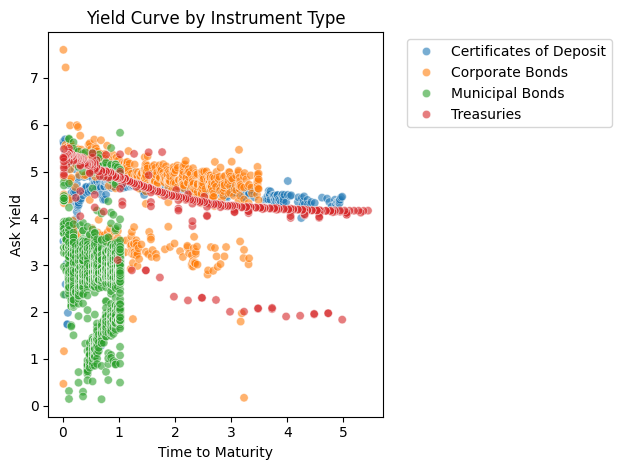

In [94]:
sns.scatterplot(
    data=df,
    x="time_to_maturity_ttm",
    y="ask_yield",
    hue="instrument_type",
    alpha=0.6
)

plt.title("Yield Curve by Instrument Type")
plt.xlabel("Time to Maturity")
plt.ylabel("Ask Yield")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


<Axes: xlabel='instrument_type', ylabel='ask_yield'>

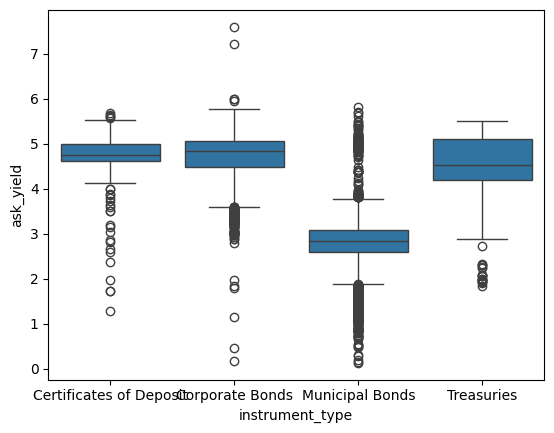

In [95]:
sns.boxplot(
    data = df,
    x = "instrument_type",
    y = "ask_yield"
)

<Axes: xlabel='duration_pct__', ylabel='ask_yield'>

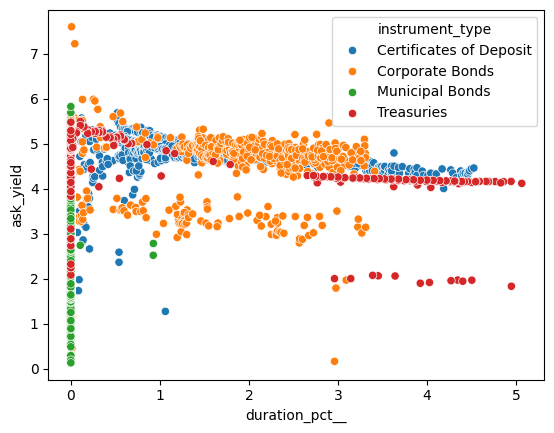

In [96]:
sns.scatterplot(
    data = df,
    x = "duration_pct__",
    y = "ask_yield",
    hue = "instrument_type"
    
)

<Axes: xlabel='instrument_type', ylabel='bid_ask_spread_bps'>

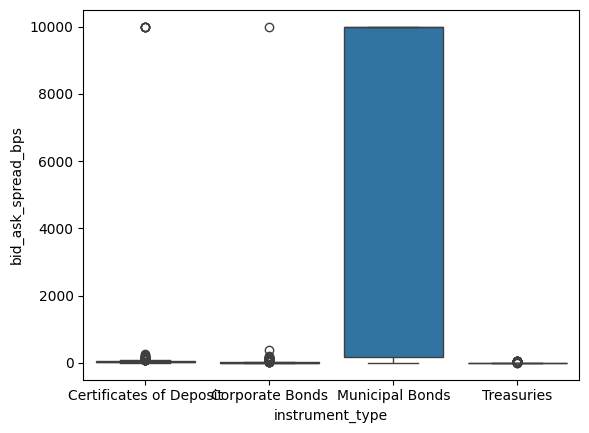

In [98]:
df["bid_ask_spread"] = df["ask"] - df["bid"]
df["bid_ask_spread_bps"] = df["bid_ask_spread"] / df["ask"] * 10_000


sns.boxplot(
    data=df,
    x="instrument_type",
    y="bid_ask_spread_bps"
)

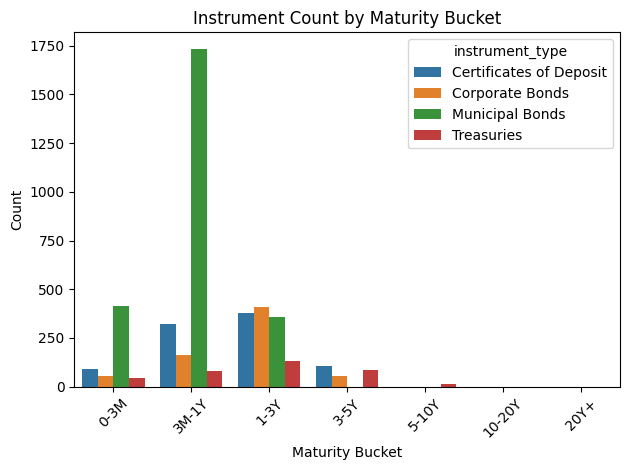

In [99]:
bins = [0, 0.25, 1, 3, 5, 10, 20, 50]
labels = ["0-3M", "3M-1Y", "1-3Y", "3-5Y", "5-10Y", "10-20Y", "20Y+"]

df["maturity_bucket"] = pd.cut(
    df["time_to_maturity_ttm"],
    bins=bins,
    labels=labels
)

sns.countplot(
    data=df,
    x="maturity_bucket",
    hue="instrument_type"
)

plt.title("Instrument Count by Maturity Bucket")
plt.xlabel("Maturity Bucket")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


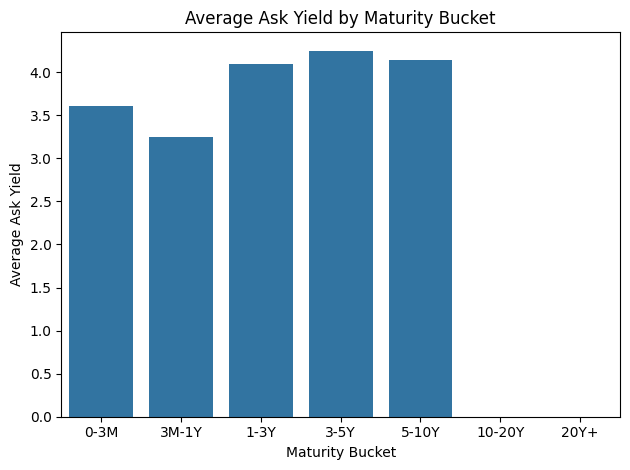

In [100]:
bucket_yield = (
    df.groupby("maturity_bucket", observed=True)["ask_yield"]
      .mean()
      .reset_index()
)

sns.barplot(
    data=bucket_yield,
    x="maturity_bucket",
    y="ask_yield"
)

plt.title("Average Ask Yield by Maturity Bucket")
plt.xlabel("Maturity Bucket")
plt.ylabel("Average Ask Yield")
plt.tight_layout()
plt.show()


<Axes: xlabel='coupon', ylabel='ask_yield'>

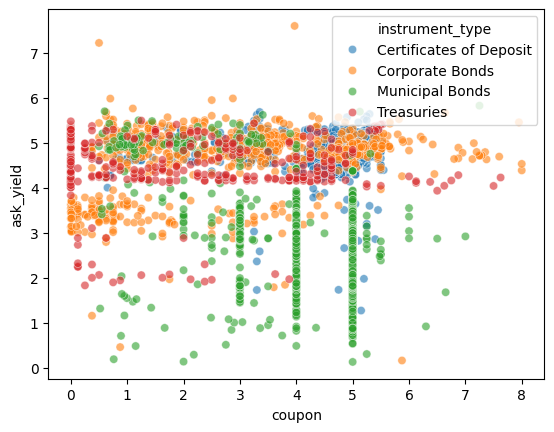

In [102]:
sns.scatterplot(
    data = df,
    x = "coupon",
    y = "ask_yield",
    hue = "instrument_type",
    alpha = .6
)

<Axes: xlabel='duration_pct__', ylabel='convexity'>

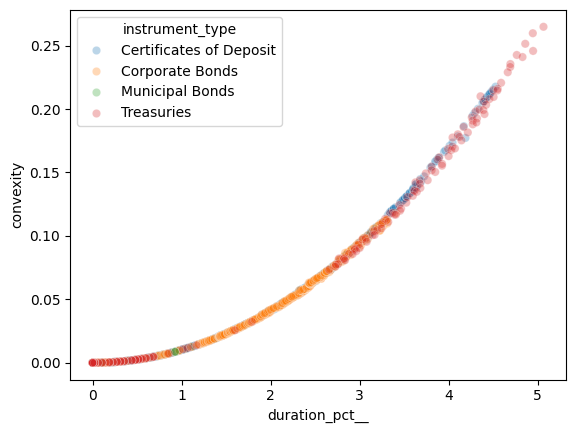

In [105]:
sns.scatterplot(
    data = df,
    x = "duration_pct__",
    y = "convexity",
    hue = "instrument_type",
    alpha = .3
)

<Axes: xlabel='shock_100bps_pct', ylabel='financial_instrument'>

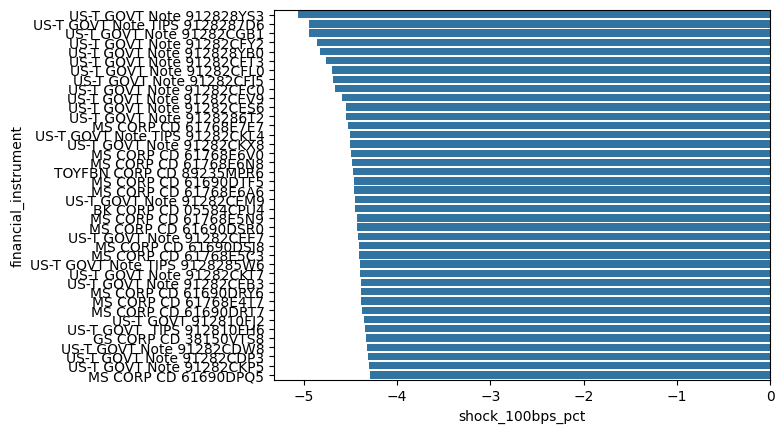

In [113]:
shock = 0.01

df["shock_100bps_pct"] = -df["duration_pct__"] * shock * 100

top_shock = (
    df.sort_values("shock_100bps_pct")
        .head(40)
)

bottom_shock = (
    df.sort_values("shock_100bps_pct", ascending = False)
        .head(15)
)

sns.barplot(
    data = top_shock,
    y = "financial_instrument",
    x = "shock_100bps_pct"
)


<Axes: xlabel='shock_100bps_pct', ylabel='financial_instrument'>

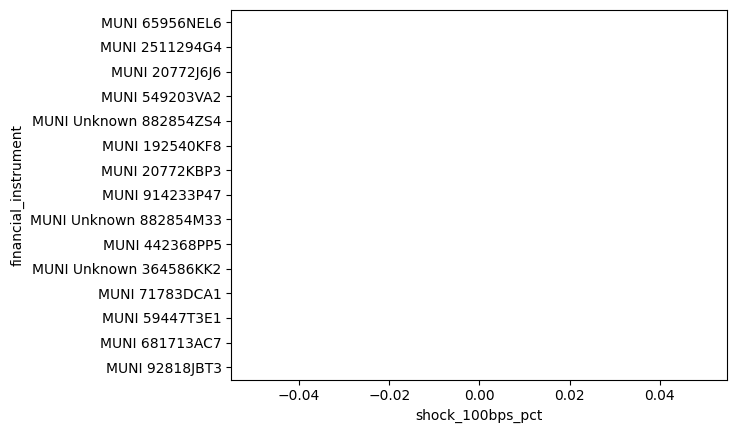

In [114]:
sns.barplot(
    data = bottom_shock,
    y = "financial_instrument",
    x = "shock_100bps_pct"
)